Name: Se Rang Seo (Simon)

Professor: Dr. Romanowsky

Course: Phys255 Machine Learning

# About

The topic I am going to choose is going to be medical science. I’m going to use this article. This article is a statistical study done on German patients aged 65 and above with chronic diseases such as: hypertension, diabetes, cancer, heart failure, and so on. There are a total of around 840,000 patients: 42% male and 56% female. The reason for this study was to analyze the general public’s health in elderly patients in Germany while the conclusion they found was that chronic disease was high for German elders and that hypertension was the highest chronic disease for 25% of the patients.

https://datadryad.org/dataset/doi:10.5061/dryad.qh0h1#usage

https://journals.publisso.de/en/journals/gms/volume14/000230


### Chronic Diseases:

$\bf{Hypertension}$ or High Blood Pressure: a common condition where the force of blood against the artery walls is consistently too high. This can lead to serious health issues, including heart disease and stroke

$\bf{CHD}$ (Coronary Heart Disease) or Ischemic Heart Diease: a type of heart disease involving the reduction of blood flow to the cardiac muscle due to a build-up of atheromatous plaque in the arteries of the heart.

$\bf{Lipid}$ Disorder: the most common type of heart disease and the leading cause of death in the United States. It occurs when the coronary arteries become narrowed or blocked due to the buildup of atheromatous plaque, which reduces blood flow to the heart muscle

$\bf{Stroke}$: the blood supply to part of the brain is blocked or reduced

$\bf{Heart Failure}$ or Congestive Heart Failure: a chronic condition where the heart muscle is unable to pump enough blood to meet the body's needs for blood and oxygen. 

$\bf{Cancer}$: a disease in which some of the body’s cells grow uncontrollably and spread to other parts of the body

$\bf{Diabetes}$: a condition that happens when your blood sugar (glucose) is too high. It develops when your pancreas doesn’t make enough insulin or any at all, or when your body isn’t responding to the effects of insulin properly.

$\bf{COPD}$ (Chronic Obstructive Pulmonary Disease): a progressive lung disease that makes it difficult to breathe, primarily caused by long-term exposure to irritants like cigarette smoke and air pollution.

$\bf{Osteoporosis}$: a bone disease characterized by weak and fragile bones, increasing the risk of fractures

$\bf{Chronic Kidney Disease}$: your kidneys slowly get damaged and can't do important jobs like removing waste and keeping blood pressure normal

# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn import metrics
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import pyreadstat

#pip install pandas openpyxl
#pip install xlrd

# Dataset

In [2]:
dataset = pd.read_excel('cd2014.xls')

In [3]:
dataset

,patient,male_gender,age,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,68,1,0,1,0,0,0,0,0,0,0
1,2,0,78,1,0,0,0,0,0,0,0,1,0
2,3,0,78,0,0,0,0,0,0,0,0,0,0
3,4,0,92,0,0,1,0,0,0,0,0,1,0
4,5,1,73,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1,80,1,1,1,0,0,0,0,0,0,0
9996,9997,0,67,1,0,1,0,0,0,0,0,0,0
9997,9998,0,90,0,0,0,0,0,0,0,0,0,0
9998,9999,0,67,0,0,0,0,0,1,0,0,0,0


### Gender 
1 is male and 0 is female

1 is yes and 0 is no

In [4]:
dataset.head()

,patient,male_gender,age,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,68,1,0,1,0,0,0,0,0,0,0
1,2,0,78,1,0,0,0,0,0,0,0,1,0
2,3,0,78,0,0,0,0,0,0,0,0,0,0
3,4,0,92,0,0,1,0,0,0,0,0,1,0
4,5,1,73,1,0,1,0,0,0,0,0,0,0


I think I should drop the patient number and age. Age is not too important since we are, in general, studying elderly patients, so whether they are 70 or 95, they are elderly people.
I will also drop nulls, although I don't see any.

In [5]:
dropnaset = dataset.dropna()
dropnaset = dropnaset.drop(columns=['patient'])
binaryset = dropnaset.drop(columns=['age'])

binaryset

,male_gender,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,1,0
4,1,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,1,0,0,0,0,0,0,0
9996,0,1,0,1,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,1,0,0,0,0


In [6]:
setlist = [col for col in binaryset.columns]

for i in setlist:
    print(binaryset[i].value_counts())
    print(f"Ratio: {binaryset[i].value_counts()[1]/(binaryset[i].value_counts()[0]+binaryset[i].value_counts()[1])*100:.2f}%",'\n')

male_gender
0    5817
1    4183
Name: count, dtype: int64
Ratio: 41.83% 

Hypertension
1    6712
0    3288
Name: count, dtype: int64
Ratio: 67.12% 

CHD
0    7426
1    2574
Name: count, dtype: int64
Ratio: 25.74% 

Lipid_disorder
0    5880
1    4120
Name: count, dtype: int64
Ratio: 41.20% 

Stroke
0    9373
1     627
Name: count, dtype: int64
Ratio: 6.27% 

Heart_failure
0    8431
1    1569
Name: count, dtype: int64
Ratio: 15.69% 

Cancer
0    8287
1    1713
Name: count, dtype: int64
Ratio: 17.13% 

Diabetes
0    6856
1    3144
Name: count, dtype: int64
Ratio: 31.44% 

COPD
0    8711
1    1289
Name: count, dtype: int64
Ratio: 12.89% 

Osteoporosis
0    8707
1    1293
Name: count, dtype: int64
Ratio: 12.93% 

Chronic_kidney_disease
0    8699
1    1301
Name: count, dtype: int64
Ratio: 13.01% 



None of my data is balanced so I will not be using accuracy as a metric.

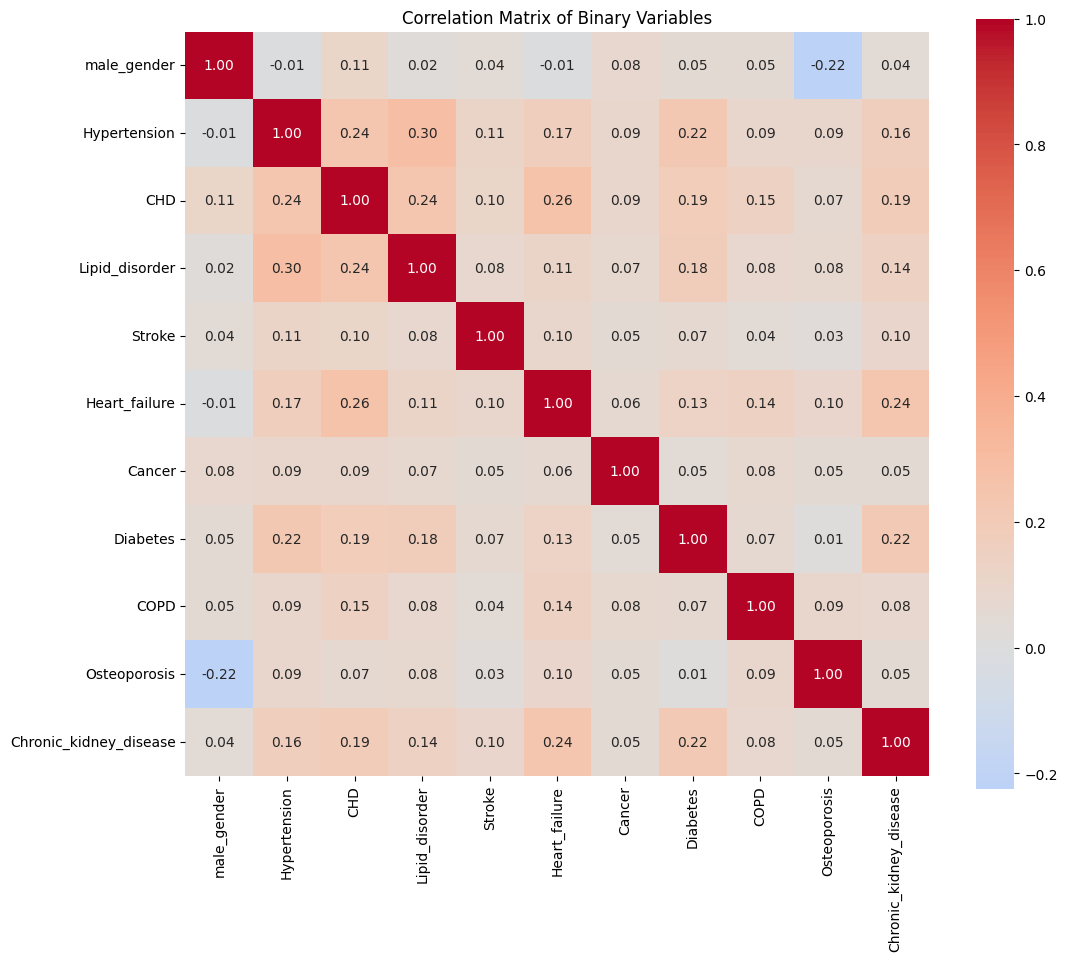

In [7]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(binaryset.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True)
plt.title('Correlation Matrix of Binary Variables')
plt.show()

Osteoporosis is less common for men.

Liquid disorder and hypertension are related.

In [8]:
# Calculate correlation matrix
corr_matrix = binaryset.corr()

# Get upper triangle of correlation matrix (excluding diagonal)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Stack and sort correlations
corr_pairs = upper_triangle.stack().sort_values(ascending=False)

# Display highest correlations
print("Highest Correlations (Top 10):")
print(corr_pairs.head(10))
print("\nLowest Correlations (Bottom 10):")
print(corr_pairs.tail(10))

Highest Correlations (Top 10):
Hypertension    Lipid_disorder            0.296536
CHD             Heart_failure             0.259815
                Lipid_disorder            0.243281
Hypertension    CHD                       0.240682
Heart_failure   Chronic_kidney_disease    0.236093
Hypertension    Diabetes                  0.222711
Diabetes        Chronic_kidney_disease    0.218944
CHD             Chronic_kidney_disease    0.191135
                Diabetes                  0.186092
Lipid_disorder  Diabetes                  0.178401
dtype: float64

Lowest Correlations (Bottom 10):
Chronic_kidney_disease  Hypertension             NaN
                        CHD                      NaN
                        Lipid_disorder           NaN
                        Stroke                   NaN
                        Heart_failure            NaN
                        Cancer                   NaN
                        Diabetes                 NaN
                        COPD           

There's certain correlations where it's about .20, so they might be too strong and can mess with the training.
Like lipid disorder and hypertension are ~ .30 while the average is around .1

# Creating Pairplot

Create a pairplot to see if I can detect stroke or cancer.

In [9]:
stroke_list = [col for col in dropnaset.columns if (col != "Stroke")]

stroke_list

['male_gender',
 'age',
 'Hypertension',
 'CHD',
 'Lipid_disorder',
 'Heart_failure',
 'Cancer',
 'Diabetes',
 'COPD',
 'Osteoporosis',
 'Chronic_kidney_disease']

In [10]:
"""sns.pairplot(dropnaset, vars=stroke_list, hue="Stroke", plot_kws={"s":15,"alpha":0.7}, corner=True)
plt.suptitle("Pairplot with target: Stroke", y=1.02)
plt.show()"""

'sns.pairplot(dropnaset, vars=stroke_list, hue="Stroke", plot_kws={"s":15,"alpha":0.7}, corner=True)\nplt.suptitle("Pairplot with target: Stroke", y=1.02)\nplt.show()'

In [11]:
cancer_list = [col for col in dropnaset.columns if (col != "Cancer")]

cancer_list

['male_gender',
 'age',
 'Hypertension',
 'CHD',
 'Lipid_disorder',
 'Stroke',
 'Heart_failure',
 'Diabetes',
 'COPD',
 'Osteoporosis',
 'Chronic_kidney_disease']

In [12]:
"""sns.pairplot(dropnaset, vars=stroke_list, hue="Cancer", plot_kws={"s":15,"alpha":0.7}, corner=True)
plt.suptitle("Pairplot with target: Cancer", y=1.02)
plt.show()"""

'sns.pairplot(dropnaset, vars=stroke_list, hue="Cancer", plot_kws={"s":15,"alpha":0.7}, corner=True)\nplt.suptitle("Pairplot with target: Cancer", y=1.02)\nplt.show()'

The dataset will not be balanced since I will be training 10 paramters to a single target. The metric I will be using is precision or recall. I won't be using accuracy since the dataset is not balanced

The method I would use is random forest classifier or a different classifier that's good for binary dataset.

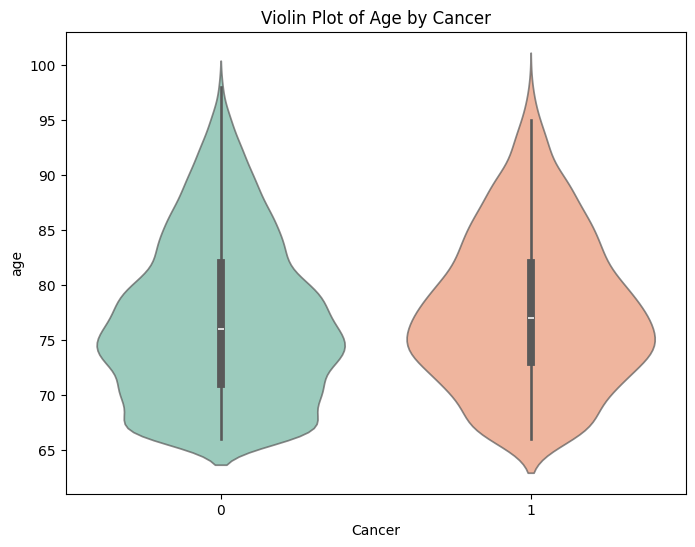

In [13]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=dropnaset, x="Cancer", y="age", 
               hue="Cancer", palette="Set2", alpha=0.7, legend=False)
plt.title("Violin Plot of Age by Cancer")
plt.show()

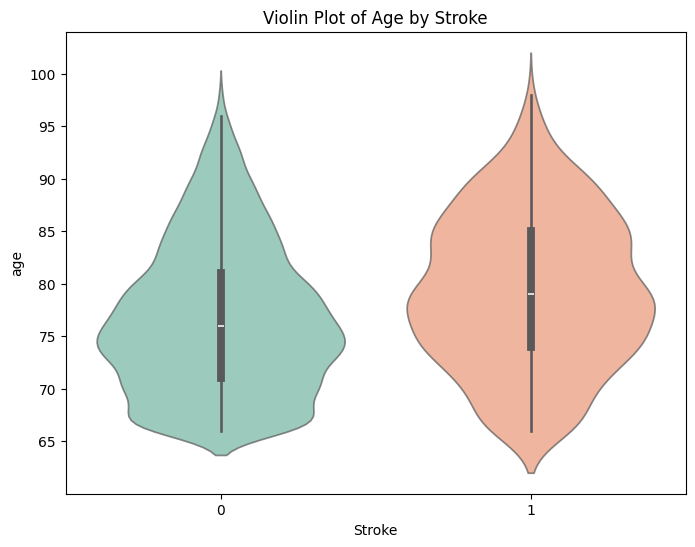

In [14]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=dropnaset, x="Stroke", y="age", 
               hue="Stroke", palette="Set2", alpha=0.7, legend=False)
plt.title("Violin Plot of Age by Stroke")
plt.show()

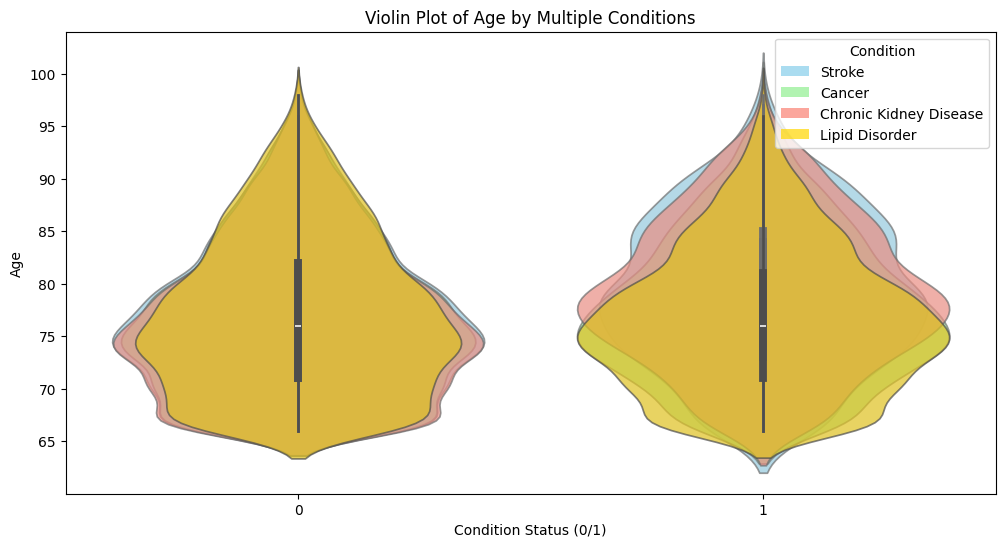

In [15]:
plt.figure(figsize=(12, 6))

# Plot all four with custom colors
stroke_plot = sns.violinplot(data=dropnaset, x="Stroke", y="age", 
                              color="skyblue", alpha=0.7, 
                              label="Stroke")
cancer_plot = sns.violinplot(data=dropnaset, x="Cancer", y="age", 
                             color="lightgreen", alpha=0.7, 
                             label="Cancer")
ckd_plot = sns.violinplot(data=dropnaset, x="Chronic_kidney_disease", y="age", 
                          color="salmon", alpha=0.7, 
                          label="Chronic Kidney Disease")
lipid_plot = sns.violinplot(data=dropnaset, x="Lipid_disorder", y="age", 
                            color="gold", alpha=0.7, 
                            label="Lipid Disorder")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='skyblue', alpha=0.7, label='Stroke'),
    Patch(facecolor='lightgreen', alpha=0.7, label='Cancer'),
    Patch(facecolor='salmon', alpha=0.7, label='Chronic Kidney Disease'),
    Patch(facecolor='gold', alpha=0.7, label='Lipid Disorder')
]
plt.legend(handles=legend_elements, title="Condition", loc='upper right')

plt.title("Violin Plot of Age by Multiple Conditions")
plt.xlabel("Condition Status (0/1)")
plt.ylabel("Age")
plt.show()

In [16]:
# List of conditions (exclude male_gender and age)
conditions = ['Hypertension', 'CHD', 'Lipid_disorder', 'Stroke', 
              'Heart_failure', 'Cancer', 'Diabetes', 'COPD', 
              'Osteoporosis', 'Chronic_kidney_disease']

"""# Color palette for conditions
colors = plt.cm.Set3(range(len(conditions)))

# Create separate plots
for condition, color in zip(conditions, colors):
    plt.figure(figsize=(8, 6))
    sns.violinplot(data=dropnaset, x=condition, y='age', 
                   color=color, alpha=0.7)
    plt.title(f'Age Distribution by {condition.replace("_", " ").title()}')
    plt.xlabel(f'{condition.replace("_", " ").title()} (0=No, 1=Yes)')
    plt.ylabel('Age')
    plt.show()""";

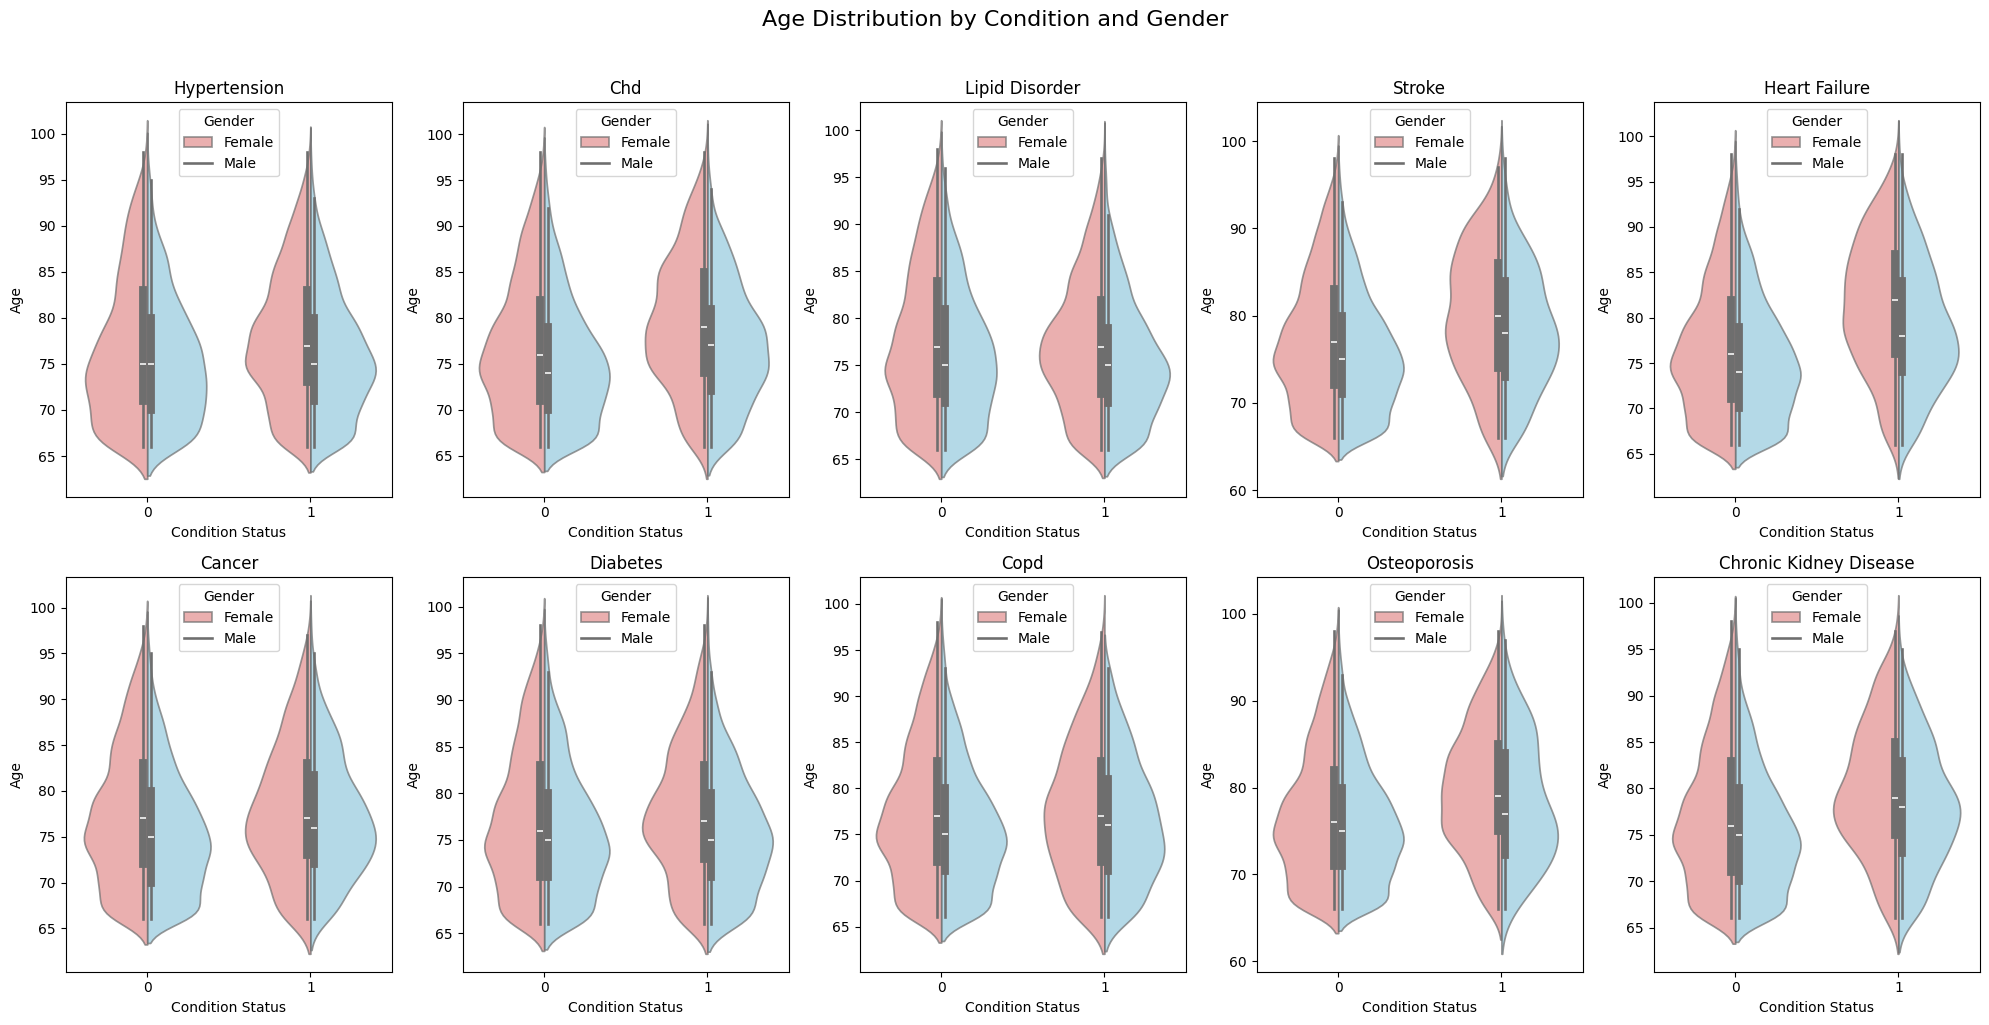

In [17]:
# Gender-stratified violin plots for each condition
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, condition in enumerate(conditions):
    sns.violinplot(data=dropnaset, x=condition, y='age', 
                   hue='male_gender', split=True,
                   palette={0: 'lightcoral', 1: 'skyblue'},  # Fixed: use 0 and 1
                   alpha=0.7, ax=axes[idx])
    axes[idx].set_title(f'{condition.replace("_", " ").title()}')
    axes[idx].set_xlabel('Condition Status')
    axes[idx].set_ylabel('Age')
    axes[idx].legend(title='Gender', labels=['Female', 'Male'])  # Fixed: labels in order

plt.suptitle('Age Distribution by Condition and Gender', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight={0: 1, 1: 10},  # Give stroke cases 10x importance
    verbose=1)
rf_model.get_params()

X = dropnaset.drop('Stroke', axis=1) # Features (excluding target)
y = dropnaset['Stroke']  # Target variable

X_train0, X_test0, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,  # Increased from 0.2 to 0.3 (30% test, 70% train)
    random_state=42,  # Remove or change this to None for different random splits each time
    stratify=y,
    shuffle=True  # Explicitly shuffle (True by default, but good to specify)
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train0)
X_test = scaler.transform(X_test0)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [19]:
# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
    
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.8970
Precision: 0.8908
Recall: 0.8970
F1-Score: 0.8939

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      2812
           1       0.13      0.12      0.12       188

    accuracy                           0.90      3000
   macro avg       0.54      0.53      0.53      3000
weighted avg       0.89      0.90      0.89      3000


Confusion Matrix:
[[2669  143]
 [ 166   22]]


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Random Forest Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-validation Score: 0.1449

--- Training Set Performance ---
Training Precision: 0.3038
Training Accuracy: 0.8791
Training Recall: 0.7175
Training F1-Score: 0.4268

--- Confusion Matrix ---
[[5839  722]
 [ 124  315]]


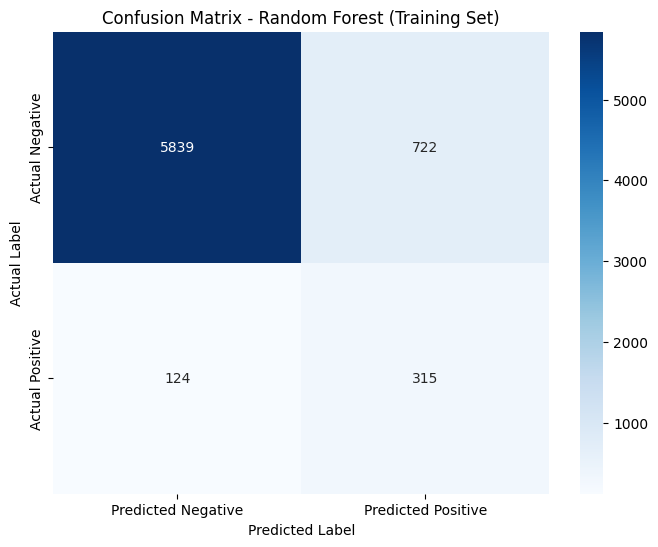

In [20]:
# Tune Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 4],  # Add this
    'class_weight': ['balanced', 'balanced_subsample']  # Try weighting
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest Random Forest Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

# Make predictions on test set
y_train_pred = grid_search.predict(X_train)

print(f"\n--- Training Set Performance ---")
print(f"Training Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Training Recall: {recall_score(y_train, y_train_pred):.4f}")
print(f"Training F1-Score: {f1_score(y_train, y_train_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)

print(f"\n--- Confusion Matrix ---")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - Random Forest (Training Set)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Compare this with randomness.

-5% of people have stroke, randomly chose 5%, what would the confusion matrix look like

baseline model compare with machine learning model

-clustering

In [21]:
usdiseaseset = pd.read_csv("media_deaths_results.csv")

usdiseaseset

,cause,year,deaths,deaths_share,fox_mentions,nyt_mentions,wapo_mentions,us_mentions,fox_share,nyt_share,wapo_share,us_share,fox_single_mentions,nyt_single_mentions,wapo_single_mentions,us_single_mentions,fox_single_share,nyt_single_share,wapo_single_share,us_single_share
0,accidents,2023,181146.0,7.847,1189.0,1489.0,697.0,25656.0,6.127,9.656,5.901,6.038,3820.0,5242.0,3534.0,129877.0,10.085,14.113,11.924,12.399
1,alzheimers,2023,114034.0,4.940,185.0,131.0,161.0,5723.0,0.953,0.849,1.363,1.347,426.0,473.0,531.0,13994.0,1.125,1.273,1.792,1.336
2,cancer,2023,613352.0,26.569,735.0,625.0,554.0,29785.0,3.787,4.053,4.690,7.010,1808.0,2163.0,1663.0,73971.0,4.773,5.823,5.611,7.062
3,covid,2023,49932.0,2.163,1160.0,822.0,932.0,42957.0,5.977,5.330,7.890,10.110,3378.0,3886.0,3573.0,149504.0,8.918,10.462,12.056,14.272
4,diabetes,2023,95190.0,4.123,112.0,220.0,158.0,6735.0,0.577,1.427,1.338,1.585,375.0,653.0,504.0,18718.0,0.990,1.758,1.701,1.787
5,drug overdose,2023,41552.0,1.800,1896.0,1152.0,1119.0,36557.0,9.770,7.470,9.473,8.604,3175.0,2191.0,1841.0,63415.0,8.382,5.899,6.212,6.054
6,heart disease,2023,680981.0,29.498,446.0,436.0,337.0,14845.0,2.298,2.827,2.853,3.494,912.0,1028.0,820.0,32196.0,2.408,2.768,2.767,3.074
7,homicide,2023,22390.0,0.970,10170.0,6469.0,5418.0,187274.0,52.404,41.949,45.869,44.076,16959.0,12907.0,11373.0,392661.0,44.773,34.749,38.374,37.485
8,influenza,2023,45185.0,1.957,232.0,241.0,235.0,7270.0,1.195,1.563,1.990,1.711,465.0,592.0,487.0,16126.0,1.228,1.594,1.643,1.539
9,kidney,2023,55253.0,2.393,32.0,63.0,51.0,1922.0,0.165,0.409,0.432,0.452,90.0,274.0,135.0,5142.0,0.238,0.738,0.456,0.491


In [22]:
usdiseaseset.columns.tolist()

['cause',
 'year',
 'deaths',
 'deaths_share',
 'fox_mentions',
 'nyt_mentions',
 'wapo_mentions',
 'us_mentions',
 'fox_share',
 'nyt_share',
 'wapo_share',
 'us_share',
 'fox_single_mentions',
 'nyt_single_mentions',
 'wapo_single_mentions',
 'us_single_mentions',
 'fox_single_share',
 'nyt_single_share',
 'wapo_single_share',
 'us_single_share']

In [23]:
df, meta = pyreadstat.read_sav('dataset.sav')
df

,Number,Gender,Length,Bodyweight,Financial_distress,Smoking,PAM1,PAM2,PAM3,PAM4,...,SUPP_Total_score,Total_comorbidities,Disease,Education_level,Care_allowance,Disease_duration,Medication_DM,Disease_severity,GFR,Charlson
0,1.0,2.0,165.0,81.0,1.0,2.0,3.0,2.0,3.0,2.0,...,56.0,0.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0
1,2.0,1.0,180.0,89.0,1.0,2.0,4.0,4.0,4.0,2.0,...,64.0,1.0,1.0,2.0,0.0,0.0,1.0,1.0,NaN,2.0
2,3.0,1.0,170.0,80.0,2.0,2.0,3.0,2.0,4.0,2.0,...,47.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,3.0
3,4.0,1.0,198.0,120.0,2.0,2.0,2.0,5.0,3.0,3.0,...,84.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,NaN,2.0
4,5.0,1.0,186.0,107.0,3.0,2.0,4.0,3.0,3.0,2.0,...,53.0,2.0,1.0,3.0,0.0,1.0,1.0,1.0,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,1010.0,2.0,169.0,68.0,1.0,1.0,3.0,3.0,3.0,3.0,...,80.0,1.0,4.0,1.0,0.0,NaN,NaN,0.0,2.0,3.0
1150,1011.0,2.0,160.0,70.0,2.0,1.0,3.0,3.0,2.0,3.0,...,67.0,0.0,4.0,2.0,NaN,1.0,NaN,0.0,2.0,2.0
1151,1012.0,2.0,169.0,65.0,1.0,1.0,3.0,3.0,3.0,3.0,...,75.0,2.0,4.0,1.0,0.0,NaN,NaN,0.0,2.0,4.0
1152,1013.0,1.0,184.0,85.0,2.0,2.0,3.0,3.0,3.0,3.0,...,78.0,3.0,4.0,2.0,1.0,NaN,NaN,1.0,1.0,6.0


In [24]:
df = pd.read_stata('dtafile.dta')

# Quick overview
print(df.shape)  # Rows, columns
print(df.head())  # First few rows
print(df.info())  # Data types and missing values

(5914, 54)
         id age_h  gender h211a h301 h302 h302a h308                  h309a  \
0  01020009    60  female   MoH   no  NaN   NaN   no  arterial hypertension   
1  01020034    58  female  IMSS   no  NaN   NaN   no             depression   
2  01020037    43    male  IMSS   no  NaN   NaN   no  arterial hypertension   
3  01020039    60    male  IMSS   no  NaN   NaN   no          heart disease   
4  01020043    58    male   MoH   no  NaN   NaN   no               diabetes   

  h311  ...       vc_uci cp_med_gral_3_p cp_med_esp_3_p  cp_laboratorio_p  \
0   no  ...  1025.900024       25.916000       1.999500               0.0   
1   no  ...  2387.100098       90.691200      84.796806               0.0   
2   no  ...  2387.100098      106.215302      15.176701               0.0   
3   no  ...  2387.100098       76.309196     208.458801               0.0   
4   no  ...  1025.900024       24.754402       1.122300               0.0   

  cp_medicamento_p cp_piso_p cp_uci_p cp_consulta_p

In [25]:
df

,id,age_h,gender,h211a,h301,h302,h302a,h308,h309a,h311,...,vc_uci,cp_med_gral_3_p,cp_med_esp_3_p,cp_laboratorio_p,cp_medicamento_p,cp_piso_p,cp_uci_p,cp_consulta_p,cp_hospi_p,costo_p
0,01020009,60,female,MoH,no,NaN,NaN,no,arterial hypertension,no,...,1025.900024,25.916000,1.999500,0.0,0.0,0.000000,0.0,27.915501,0.000000,27.915501
1,01020034,58,female,IMSS,no,NaN,NaN,no,depression,no,...,2387.100098,90.691200,84.796806,0.0,0.0,0.000000,0.0,175.488007,0.000000,175.488007
2,01020037,43,male,IMSS,no,NaN,NaN,no,arterial hypertension,no,...,2387.100098,106.215302,15.176701,0.0,0.0,0.000000,0.0,121.391998,0.000000,121.391998
3,01020039,60,male,IMSS,no,NaN,NaN,no,heart disease,no,...,2387.100098,76.309196,208.458801,0.0,0.0,0.000000,0.0,284.768005,0.000000,284.768005
4,01020043,58,male,MoH,no,NaN,NaN,no,diabetes,no,...,1025.900024,24.754402,1.122300,0.0,0.0,0.000000,0.0,25.876701,0.000000,25.876701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5909,32021824,26,male,MoH,yes,gastritis,no,no,gastritis,no,...,1025.900024,15.364800,0.696600,0.0,0.0,0.000000,0.0,16.061401,0.000000,16.061401
5910,32021825,61,male,MoH,no,NaN,NaN,no,arterial hypertension,no,...,1025.900024,25.916000,1.999500,0.0,0.0,0.000000,0.0,27.915501,0.000000,27.915501
5911,32021844,39,female,MoH,yes,chronic obstructive pulmonary disease,yes,no,asthma,yes,...,1025.900024,30.800001,0.000000,0.0,0.0,558.599976,0.0,30.800001,558.599976,589.399963
5912,32021848,41,female,MoH,no,NaN,NaN,no,colitis,no,...,1025.900024,12.988800,4.179600,0.0,0.0,0.000000,0.0,17.168400,0.000000,17.168400


In [26]:
# Load the Excel file
df = pd.read_excel('questionxlsx.xlsx')

df

,ID,Age,regappt (yes=0/no=1),hosp admissions,wtchart,lungfunction,CRP,glucose,other,VALUABLE FOR,...,addownclinmeasure,rptprescription,preinterview,bookappt,feedback,errors.1,experience.1,importantquestions,callback,knowldgeportal
0,NaN,o 6,For all scores 1 (very important) to 6 (very u...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,21,0,0.0,2.0,1.0,1.0,2.0,NaN,NaN,...,10.0,1.0,8.0,2.0,9.0,15.0,11.0,12.0,13.0,14.0
2,2.0,32,0,2.0,1.0,1.0,1.0,2.0,NaN,NaN,...,8.0,6.0,2.0,3.0,12.0,13.0,14.0,4.0,5.0,15.0
3,3.0,26,0,3.0,1.0,1.0,2.0,4.0,NaN,NaN,...,8.0,4.0,11.0,6.0,7.0,9.0,14.0,13.0,10.0,15.0
4,4.0,20,0,3.0,1.0,1.0,1.0,2.0,NaN,NaN,...,7.0,6.0,8.0,9.0,10.0,13.0,11.0,12.0,14.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,197.0,45,0,0.0,4.0,1.0,3.0,2.0,NaN,NaN,...,8.0,13.0,9.0,2.0,7.0,10.0,15.0,14.0,1.0,6.0
198,198.0,33,0,3.0,3.0,1.0,2.0,2.0,NaN,NaN,...,4.0,15.0,7.0,13.0,5.0,9.0,6.0,14.0,11.0,8.0
199,199.0,41,0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,...,3.0,11.0,4.0,15.0,9.0,12.0,13.0,5.0,6.0,14.0
200,200.0,31,0,2.0,2.0,1.0,2.0,2.0,2sats,NaN,...,11.0,8.0,10.0,5.0,12.0,13.0,9.0,15.0,4.0,14.0


In [27]:
feature_list = df.columns.tolist()
print(feature_list)

['ID', 'Age', 'regappt (yes=0/no=1)', 'hosp admissions', 'wtchart', 'lungfunction', 'CRP', 'glucose', 'other', 'VALUABLE FOR', 'medications', 'sputum', 'blood results', 'allergies', 'bone results', 'datesprocedures', 'alertrpttests', 'alertoverduetests', 'GP letters', 'links', 'other.1', 'EMR', 'wtchart.1', 'lungfunct', 'CRP.1', 'BG', 'List Meds', 'Changes meds', 'GP letters.1', 'Vit levels', 'bonescan', 'allergies.1', 'genetics', 'DatesAb', 'What Ab', 'Dateadmission', 'Vaccination', 'Refdepts', 'Summary', 'Reminders', 'Accesssputum', 'Accessblood', 'Appointments', 'Sending information', 'rptprescriptions', 'ordertreatment', '02sats', 'BP', 'Lungfunction', 'Weight', 'BG.1', 'symptoms', 'exercise', 'PERTdiary', 'Pain', 'Pre-clinicinterview', 'Mood&feelings', 'sceduleappts', 'QOL', 'Feedback', 'errors', 'experience', 'Impquestions', 'Communicate', 'Donor', 'Advdirectives', 'Unnamed: 66', 'Ranked function from 1 (highest) to 15 (lowest) of 15 functions of the ECR', 'clinmeasures', 'curren

In [28]:
elks = pd.read_excel('elks.xlsx')

elks

,Marker,Chromosome,Position,P-Value,"""-LOG10(P-Value)""",Intercept Beta,Intercept Beta SE,Predictor Beta,Predictor Beta SE,Expected P,"""-LOG10(Expected P)""",Proportion of Variance Explained,Mahal. RSS,Actual Sample Size,Call Rate
0,Affx-1306994441,10,48561743,2.743149e-08,7.561751,0.443171,0.011943,-1.854466e-01,0.033077,0.000003,5.540765,3.367523e-02,117.964862,879,0.972345
1,Affx-1308642946,10,48563132,3.365267e-08,7.472981,0.443039,0.011967,-1.850543e-01,0.033224,0.000009,5.063644,3.325002e-02,118.016771,903,0.998894
2,Affx-1308642945,10,48563133,4.062939e-08,7.391160,0.442766,0.011970,-1.842086e-01,0.033276,0.000014,4.841795,3.285806e-02,118.064619,904,1.000000
3,Affx-1308642941,10,48561608,4.816044e-08,7.317310,0.442807,0.012010,-1.829897e-01,0.033241,0.000020,4.695667,3.250427e-02,118.107809,901,0.996681
4,Affx-1306994444,10,48561876,4.945716e-08,7.305771,0.442673,0.011999,-1.845316e-01,0.033551,0.000026,4.586522,3.244899e-02,118.114557,903,0.998894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173669,Affx-1307368841,12,14855289,9.999654e-01,0.000015,0.395759,0.012861,-1.325619e-06,0.030540,0.999974,0.000011,2.088552e-12,122.075793,895,0.990044
173670,Affx-1305358039,4,9424764,9.999752e-01,0.000011,0.395759,0.021120,-7.152608e-07,0.023024,0.999980,0.000009,1.069811e-12,122.075793,900,0.995575
173671,Affx-1305082838,3,10135897,9.999862e-01,0.000006,0.395759,0.020682,-3.991434e-07,0.023126,0.999986,0.000006,3.304024e-13,122.075793,904,1.000000
173672,Affx-1305082839,3,10135935,9.999862e-01,0.000006,0.395759,0.020682,-3.991434e-07,0.023126,0.999991,0.000004,3.304024e-13,122.075793,904,1.000000


In [29]:
feature_list = elks.columns.tolist()
print(feature_list)

['Marker', 'Chromosome', 'Position', 'P-Value', '"-LOG10(P-Value)"', 'Intercept Beta', 'Intercept Beta SE', 'Predictor Beta', 'Predictor Beta SE', 'Expected P', '"-LOG10(Expected P)"', 'Proportion of Variance Explained', 'Mahal. RSS', 'Actual Sample Size', 'Call Rate']


In [31]:
# Load the TSV file
df = pd.read_csv('elkstsv.tsv', sep='\t')

C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_15040\3824572220.py:2: DtypeWarning: Columns (0: Affx-1304485939, 1: Affx-1304486080, 2: Affx-1304486086, 3: Affx-1304486115, 4: Affx-1304486163, 5: Affx-1304486235, 6: Affx-1304486696, 7: Affx-1304486881, 8: Affx-1304487006, 9: Affx-1304487030, 10: Affx-1304487103, 11: Affx-1304487249, 12: Affx-1304487423, 13: Affx-1304487439, 14: Affx-1304487526, 15: Affx-1304487695, 16: Affx-1304487714, 17: Affx-1304487720, 18: Affx-1304487826, 19: Affx-1304487883, 20: Affx-1304488012, 21: Affx-1304488309, 22: Affx-1304488459, 23: Affx-1304488522, 24: Affx-1304488918, 25: Affx-1304488934, 26: Affx-1304488948, 27: Affx-1304489039, 28: Affx-1304489081, 29: Affx-1304489457, 30: Affx-1304489461, 31: Affx-1304489464, 32: Affx-1304489680, 33: Affx-1304489714, 34: Affx-1304489773, 35: Affx-1304489835, 36: Affx-1304489961, 37: Affx-1304489967, 38: Affx-1304490049, 39: Affx-1304490154, 40: Affx-1304490427, 41: Affx-1304490487, 42: Affx-1304490528, 43: Affx-1304

In [32]:
df

,SampleID,CWD_Binary,Age,Geographic_Origin,Sex,Affx-1304485939,Affx-1304486056,Affx-1304486080,Affx-1304486086,Affx-1304486115,...,Affx-1304456518,Affx-1304456521,Affx-1304456525,Affx-1304457104,Affx-1304457311,Affx-1304457569,Affx-1304457693,Affx-1304457729,Affx-1304457732,Affx-1304458128
0,Farm AA-1_313127_F10.CEL_call_code,0,5,CAN,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,Farm AA-2_313128_A6.CEL_call_code,0,5,CAN,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2
2,Farm AA-3_313128_B5.CEL_call_code,0,5,CAN,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,Farm AA-4_313128_H6.CEL_call_code,0,5,CAN,0,2,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
4,Farm AA-5_313128_A10.CEL_call_code,0,3,CAN,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,Farm N-34_313127_H3.CEL_call_code,0,4,CAN,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
900,Farm V-12_313127_H12.CEL_call_code,1,4,CAN,0,0,0,0,0,0,...,0,0,0,0,0,2,2,2,2,0
901,Farm P-33_313127_B3.CEL_call_code,0,4,CAN,1,0,0,0,0,1,...,0,0,0,0,0,1,1,1,1,1
902,Farm M-57_313127_E1.CEL_call_code,0,14,CAN,1,0,0,0,0,0,...,2,2,2,0,0,0,0,0,0,1
